In [2]:
import os
#import deeptile
import matplotlib.pyplot as plt
import numpy as np
#from deeptile.extensions import stitch
# from tifffile import TiffFile
import tifffile
import dask.array as da
import utils
import skimage as ski

# import extract_features
import pandas as pd
#from collections import defaultdict
from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
#from scipy import ndimage as ndi
import time

In [3]:
nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/o8p_day7_s12_MASK.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/o8p_day7_s12_FOCI_MASK.tif"
img_path = "/Users/hannahbolen/Desktop/image_analysis/o8p_day7_s12.ome.tif"

results = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/o8p_day7_s12.csv")

nuclei_mask = da.from_array(tifffile.imread(nuclei_mask_path))
img_nuclei = da.from_array(tifffile.imread(img_path)[0])

In [4]:
features_update = {
    "label": lambda r: r.label,
    "intensity_mean": lambda r: r.intensity_mean,
    "intensity_max": lambda r: r.intensity_max 
}

In [5]:
dfs = []
dfs.append(
    feature_table(nuclei_mask.compute(), features_update, img_nuclei.compute())
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    results
    .set_index("label")
)



results_combine = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label")
#results_fullslide.to_csv(os.path.join(results_folder,"".join([img_path.split(".")[0], "_results.csv"])))


In [14]:
c_i = results_combine.at[4, "nuclei_i"]
c_j = results_combine.at[4, "nuclei_j"]
print(c_i, c_j)

846.3316056208247 24623.28648352914


In [ ]:
c_i = 1001
c_j = results_combine.at[4, "nuclei_j"]
fig, ax = plt.subplots(figsize=(20,20))
ax.imshow(ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(img_nuclei.compute()[int(c_i)-1000:int(c_i)+1000,int(c_j)-1000:int(c_j)+1000], in_range=(0,5000)), nuclei_mask.compute()[int(c_i)-1000:int(c_i)+1000,int(c_j)-1000:int(c_j)+1000]))
plt.show()


In [6]:
len(results_combine)

5584

In [8]:
import seaborn as sns

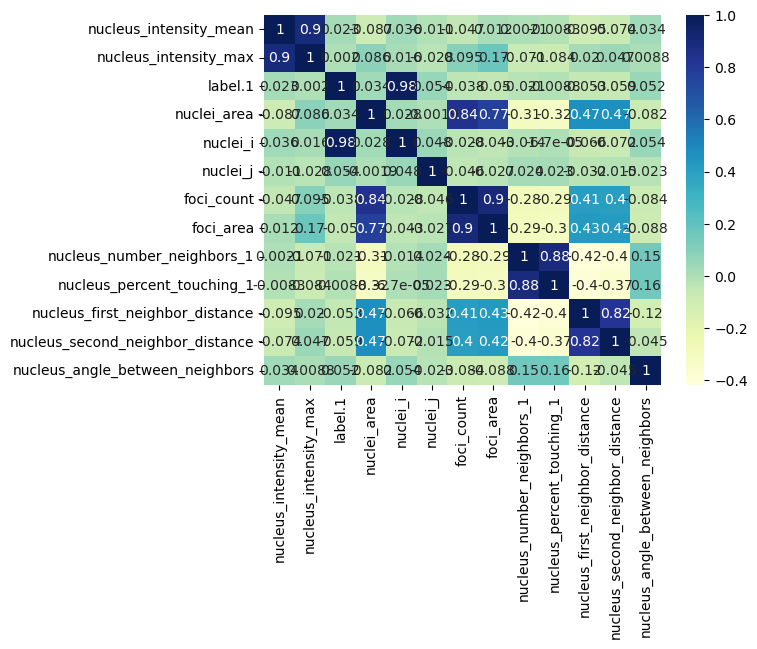

<Figure size 2000x2000 with 0 Axes>

In [11]:
# Compute correlation matrix
co_mtx = results_combine[results_combine["nucleus_intensity_mean"] > 1000].corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [30]:
results_combine[results_combine["nuclei_intensity_mean"] < 2000].describe()

,nuclei_intensity_mean,nuclei_intensity_max,label.1,nuclei_area,nuclei_i,nuclei_j,foci_count,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
count,3827.000000,3827.000000,3827.000000,3827.000000,3827.000000,3827.000000,3827.000000,3827.000000,3827.00000,3827.000000,3827.000000,3827.000000,3827.000000
mean,881.166044,1773.244317,2994.934936,1736.147635,21763.136578,15737.882563,2.877450,55.295009,0.34544,0.056652,91.803045,130.950203,93.749158
std,498.699728,1103.276227,1478.121440,2795.185882,8223.127281,5428.848173,12.685853,235.050175,0.68768,0.124454,130.047973,171.459509,50.203484
min,16.192488,56.000000,1.000000,1.000000,702.826279,2032.440000,0.000000,0.000000,0.00000,0.000000,4.308132,12.465697,0.019312
25%,461.746433,945.500000,2013.500000,1078.000000,20344.137372,12466.881903,0.000000,0.000000,0.00000,0.000000,43.423309,63.354263,51.768336
50%,767.017773,1512.000000,3113.000000,1461.000000,22658.390830,15977.737726,1.000000,14.000000,0.00000,0.000000,64.942431,93.328870,92.162761
75%,1249.421014,2390.000000,4180.500000,1881.000000,27209.548133,17749.133570,3.000000,39.000000,1.00000,0.026970,103.413675,139.368617,137.170509
max,1999.112693,13499.000000,5583.000000,81772.000000,41330.006431,39123.418430,449.000000,5372.000000,6.00000,1.000000,3541.538862,3593.657758,179.988815


In [29]:
results_combine[results_combine["nuclei_intensity_mean"] >= 2000].describe()

,nuclei_intensity_mean,nuclei_intensity_max,label.1,nuclei_area,nuclei_i,nuclei_j,foci_count,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
count,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000,1757.000000
mean,3590.539100,6621.833808,2351.567445,1318.234491,17711.903772,19289.483748,4.022766,90.770063,0.571429,0.094089,73.488880,111.168325,89.151149
std,1749.676066,3331.718948,1794.059147,1787.024161,10504.018527,6084.365983,9.847501,279.671927,0.823310,0.149356,158.869637,189.253337,49.380184
min,2001.117647,3224.000000,9.000000,1.000000,1766.726027,2165.204578,0.000000,0.000000,0.000000,0.000000,15.831527,18.366144,0.152661
25%,2480.377455,4654.000000,902.000000,732.000000,10044.905213,13771.431181,1.000000,12.000000,0.000000,0.000000,32.158238,45.149949,48.426971
50%,3118.972332,5651.000000,1589.000000,1041.000000,11525.843697,20618.186776,2.000000,39.000000,0.000000,0.000000,45.149772,70.704164,85.798704
75%,4114.405128,7385.000000,4203.000000,1442.000000,27297.323101,24185.626544,5.000000,87.000000,1.000000,0.159817,78.730058,116.430139,128.925759
max,26262.189759,38068.000000,5584.000000,49271.000000,41340.798928,39479.229690,219.000000,5056.000000,4.000000,1.000000,5209.190350,5258.282273,179.974243


In [13]:
results_combine[results_combine["nucleus_intensity_mean"] >= 1000].to_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day7_s12_filtered.csv")
#np.mean(results_combine[results_combine["nuclei_intensity_mean"] > 2000]["foci_count"])